
Stock Price Prediction with LSTM

Last Updated: July 6th, 2025

Daily Challenge: Stock Price Prediction with LSTM


👩‍🏫 👩🏿‍🏫 What You’ll learn

    How to preprocess and prepare time-series data for machine learning models.
    How to build and train an LSTM (Long Short-Term Memory) model using PyTorch.
    How to evaluate the performance of a regression model using metrics like R².


🛠️ What you will create

    A preprocessed dataset for stock price prediction.
    A trained LSTM model to predict future stock prices.


⚠️ Warning ! In this daily challenge, you need to use a VM like DigitalOcean! ⚠️


Understanding PyTorch

PyTorch is an open-source machine learning framework based on the Torch library, used for applications such as computer vision and natural language processing. It’s known for its flexibility and ease of use, making it popular for both research and production.

Key PyTorch Functions You’ll Use:

    torch.nn.Module: Base class for all neural network modules. You’ll use this to define your LSTM model.
    torch.nn.LSTM: Implements a Long Short-Term Memory (LSTM) network.
    torch.nn.Linear: Applies a linear transformation to the incoming data (i.e., a fully connected layer).
    torch.nn.Dropout: Applies dropout regularization to prevent overfitting.
    torch.optim.Adam: Implements the Adam optimization algorithm.
    torch.nn.MSELoss: Implements the Mean Squared Error loss function.
    torch.utils.data.Dataset: An abstract class representing a dataset.
    torch.utils.data.DataLoader: Combines a dataset and a sampler, and provides single- or multi-process iterators over the dataset.
    torch.Tensor: A multi-dimensional matrix containing elements of a single data type.
    torch.save and torch.load: used to save and load trained models.

For further understanding on how to use Pytorch functions, you can watch this video and this one too, good luck !


What You Need to Do

1. Install Required Libraries

Ensure you have the necessary libraries installed, including gensim, spacy, torch, and scikit-learn.

2. Load and Preprocess the Dataset

    Download the stock market dataset.
    Drop unnecessary columns and create a target column for the next day’s closing price.
    Normalize the dataset using MinMaxScaler.

3. Prepare the Dataset for Training

    Split the dataset into training, validation, and testing sets.
    Create a custom PyTorch Dataset class to handle the data.
    Use DataLoader to create iterable datasets for training and evaluation.

4. Define the LSTM Model

    Create an LSTM model using PyTorch.
    Define the model architecture, including GRU layers, dropout, and a dense layer.

5. Train the Model

    Set up the optimizer and loss function.
    Implement training and validation loops.
    Train the model for a specified number of epochs.

6. Evaluate the Model

    Calculate the R² score to evaluate the model’s performance on the test set.
    Save the scaler object for future predictions.




In [1]:
!pip install torch scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 53.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import joblib

           unix        date    symbol    open    high     low   close  \
0  1.640560e+12  12-27-2021  XRP-USDT  0.9200  0.9237  0.9200  0.9226   
1  1.640480e+12  12-26-2021  XRP-USDT  0.9252  0.9334  0.9052  0.9200   
2  1.640390e+12  12-25-2021  XRP-USDT  0.9114  0.9350  0.8981  0.9252   
3  1.640300e+12  12-24-2021  XRP-USDT  0.9941  0.9966  0.8964  0.9115   
4  1.640220e+12  12-23-2021  XRP-USDT  0.9538  1.0167  0.9372  0.9941   

    Volume XRP   Volume USDT  
0    2384512.0  2.198450e+06  
1  163438501.0  1.499400e+08  
2  250074945.0  2.302303e+08  
3  567234092.0  5.377035e+08  
4  479436230.0  4.729372e+08  
               unix         open         high          low        close  \
count  1.334000e+03  1334.000000  1334.000000  1334.000000  1334.000000   
mean   1.582978e+12     0.473318     0.495597     0.450075     0.473632   
std    3.328447e+10     0.319903     0.341216     0.297513     0.320127   
min    1.525390e+12     0.135360     0.149380     0.101290     0.135490   


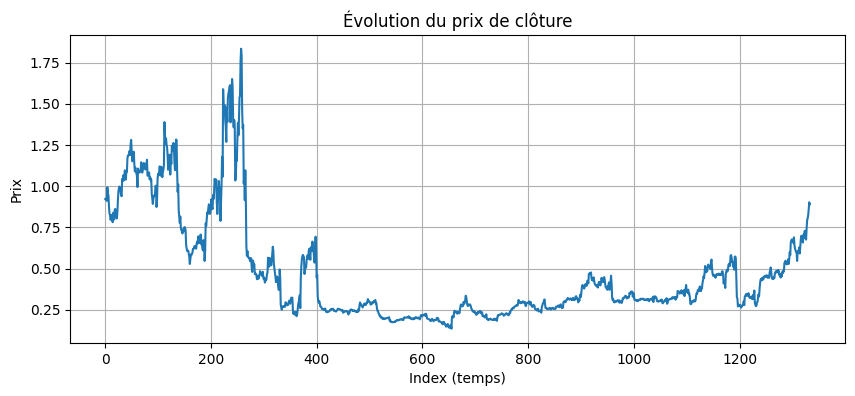

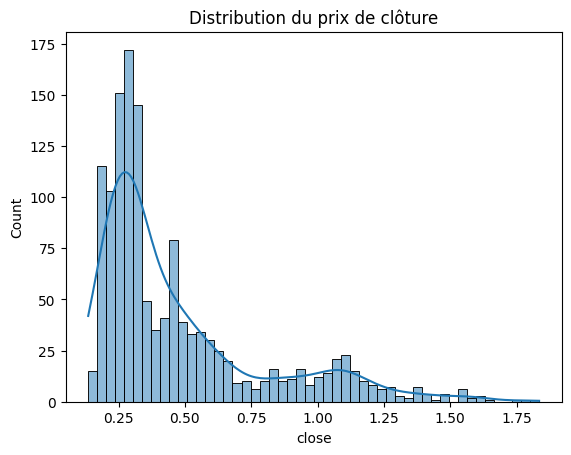

In [3]:
# charger les données
df = pd.read_csv('stock_market_dataset.csv')

# aperçu des premières lignes
print(df.head())

# description statistique
print(df.describe())

# types des colonnes et valeurs manquantes
print(df.info())

# vérifier la présence de valeurs nulles
print(df.isnull().sum())

# visualiser l’évolution des prix
plt.figure(figsize=(10, 4))
plt.plot(df['close'])
plt.title("Évolution du prix de clôture")
plt.xlabel("Index (temps)")
plt.ylabel("Prix")
plt.grid(True)
plt.show()

# distribution du prix de clôture
sns.histplot(df['close'], bins=50, kde=True)
plt.title("Distribution du prix de clôture")
plt.show()

    toutes les colonnes sont bien typées :

        open, high, low, close, volume : float64

        date, symbol : object (string)

    close est bien disponible -> utilisable comme target pour la prédiction

    la colonne unix indique un timestamp (ordre chronologique probable)

    il faudra probablement trier les données du plus ancien au plus récent avant découpage et entraînement

    close varie entre 0.13 et 1.83 -> données déjà dans un ordre de grandeur raisonnable (voir pour norma)

    médiane autour de 0.32 -> asymetrique

    grande variation sur les volumes , distribution très déséquilibrée

    Volume USDT et Volume XRP peut être corrélés

In [4]:
# créer la colonne target = close du jour suivant
df['target'] = df['close'].shift(-1)

# retirer la dernière ligne (target sera NaN)
df.dropna(inplace=True)

In [5]:
# on normalise uniquement les colonnes nécessaires
# ici close et target (on pourrait ajouter d'autres colonnes plus tard)

scaler_close = MinMaxScaler()
scaler_target = MinMaxScaler()

# reshape nécessaire car MinMaxScaler attend une 2D array
scaled_close = scaler_close.fit_transform(df[['close']])
scaled_target = scaler_target.fit_transform(df[['target']])

# reconstruction du dataframe
df_scaled = pd.DataFrame({
    'close': scaled_close.flatten(),
    'target': scaled_target.flatten()
})

transformer les données en séquences d'entrée/sortie utilisables par un réseau LSTM.

es LSTM prennent en entrée des séquences temporelles, pas des lignes isolées.
donc on doit transformer nos données scalées close en séquences glissantes de longueur fixe (appelée seq_length).
par exemple, si seq_length = 10, chaque entrée sera :

    une séquence de 10 jours consécutifs de prix close

    et la sortie sera la valeur target (prix du jour suivant)

taille de la fenêtre seq_length est un hyperparamètre : si trop court, le modèle manque de contexte ; si trop long, il apprend mal

décalage entre x et y : pour chaque séquence x, la cible y est le point juste après

on prépare donc une tâche de régression supervisée séquentielle

In [6]:
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length, 0]  # séquence de close
        y = data[i+seq_length, 1]    # valeur future (target)
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

data[i:i+seq_length, 0] = close(t-10 à t-1)

data[i+seq_length, 1] = target(t)

In [7]:
X, y = create_sequences(df_scaled[['close', 'target']].values, seq_length=10)

train_size = int(len(X) * 0.8)
val_size = int(len(X) * 0.1)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

séparation chronologique : très important pour des séries temporelles (pas de mélange aléatoire avant le split)

on évite les fuites d'information futures dans le passé

80/10/10 est un découpage standard pour cette taille de dataset (environ 1300 lignes)

In [8]:
class TimeSeriesDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = torch.tensor(sequences, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]

transforme X, y en objets PyTorch utilisables avec DataLoader

les targets sont ici des scalaires flottants -> régression

In [9]:
train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

une ou plusieurs couches LSTM : extraient les patterns temporels

une couche Dropout : régularisation pour éviter l'overfitting

une couche Linear : transforme la sortie LSTM finale en une prédiction scalaire

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)             # out shape: (batch, seq_len, hidden_size)
        out = out[:, -1, :]               # prendre la dernière sortie temporelle
        out = self.fc(out)                # projection vers la sortie
        return out.squeeze()              # suppression des dimensions inutiles

input_size=1 : on donne 1 seule feature (le close)

hidden_size=50 : taille du vecteur caché LSTM, réglable

num_layers=2 : 2 couches LSTM empilées

batch_first=True : format d'entrée : (batch, seq, feature)

on prend la dernière sortie temporelle (out[:, -1, :]) car on veut prédire à partir du contexte complet

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel(input_size=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

def train(model, train_loader, val_loader, epochs=20):
    model.train()
    for epoch in range(epochs):
        train_losses = []
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.unsqueeze(-1).to(device)  # reshape en [batch, seq, 1]
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            y_pred = model(x_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        val_losses = []
        model.eval()
        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val = x_val.unsqueeze(-1).to(device)
                y_val = y_val.to(device)
                val_pred = model(x_val)
                val_loss = loss_fn(val_pred, y_val)
                val_losses.append(val_loss.item())
        model.train()

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {np.mean(train_losses):.4f} | Val Loss: {np.mean(val_losses):.4f}")

train(model, train_loader, val_loader, epochs=20)

Epoch 1/20 | Train Loss: 0.0511 | Val Loss: 0.0043
Epoch 2/20 | Train Loss: 0.0156 | Val Loss: 0.0037
Epoch 3/20 | Train Loss: 0.0053 | Val Loss: 0.0029
Epoch 4/20 | Train Loss: 0.0038 | Val Loss: 0.0030
Epoch 5/20 | Train Loss: 0.0035 | Val Loss: 0.0031
Epoch 6/20 | Train Loss: 0.0037 | Val Loss: 0.0038
Epoch 7/20 | Train Loss: 0.0033 | Val Loss: 0.0048
Epoch 8/20 | Train Loss: 0.0037 | Val Loss: 0.0032
Epoch 9/20 | Train Loss: 0.0038 | Val Loss: 0.0039
Epoch 10/20 | Train Loss: 0.0033 | Val Loss: 0.0041
Epoch 11/20 | Train Loss: 0.0030 | Val Loss: 0.0039
Epoch 12/20 | Train Loss: 0.0032 | Val Loss: 0.0028
Epoch 13/20 | Train Loss: 0.0029 | Val Loss: 0.0029
Epoch 14/20 | Train Loss: 0.0028 | Val Loss: 0.0038
Epoch 15/20 | Train Loss: 0.0030 | Val Loss: 0.0030
Epoch 16/20 | Train Loss: 0.0027 | Val Loss: 0.0045
Epoch 17/20 | Train Loss: 0.0029 | Val Loss: 0.0026
Epoch 18/20 | Train Loss: 0.0028 | Val Loss: 0.0023
Epoch 19/20 | Train Loss: 0.0028 | Val Loss: 0.0043
Epoch 20/20 | Train L

In [13]:
model.eval()
y_pred_list = []
y_true_list = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.unsqueeze(-1).to(device)
        y_batch = y_batch.to(device)

        preds = model(x_batch)
        y_pred_list.extend(preds.cpu().numpy())
        y_true_list.extend(y_batch.cpu().numpy())

# R²
r2 = r2_score(y_true_list, y_pred_list)
print(f"R² Score (Test): {r2:.4f}")

R² Score (Test): 0.8479


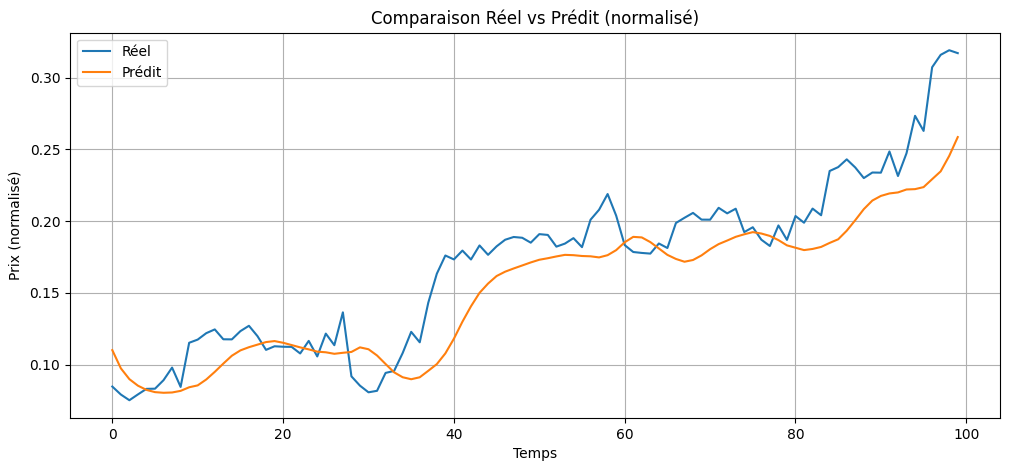

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(y_true_list[:100], label="Réel")
plt.plot(y_pred_list[:100], label="Prédit")
plt.title("Comparaison Réel vs Prédit (normalisé)")
plt.xlabel("Temps")
plt.ylabel("Prix (normalisé)")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
torch.save(model.state_dict(), "lstm_model.pth")
import joblib
joblib.dump(scaler_close, "scaler_close.pkl")
joblib.dump(scaler_target, "scaler_target.pkl")

['scaler_target.pkl']

Le train loss baisse régulièrement ➜ apprentissage stable

Le val loss reste bas (~0.002-0.004) pas d'overfitting massif

Fluctuations normales en val_loss : données financières sont bruitées et non stationnaires

Le modèle explique ~85% de la variance des prix de clôture futurs dans l'ensemble test.

En finance/économie, tout score > 0.8 en régression est très bon, surtout sans features exogènes.

Cela montre que le signal temporel dans la série close est exploitable par le modèle.